In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import glob

# Define your project paths (adjust if different)
PROJECT_ROOT = r"C:\Users\aaros\OneDrive\Documents\Remittance_Analysis"
DOWNLOADS = r"C:\Users\aaros\Downloads"

# Define subfolders
NRB_RAW = os.path.join(PROJECT_ROOT, "data", "nrb_raw")
DOFE_RAW = os.path.join(PROJECT_ROOT, "data", "dofe_raw")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "output")

# Create folders if they don't exist
for folder in [NRB_RAW, DOFE_RAW, OUTPUT_DIR]:
    os.makedirs(folder, exist_ok=True)

# Check where your files are currently located
print("=== CHECKING FILE LOCATIONS ===\n")

# Check 1: Did your previous notebook save files to nrb_raw?
nrb_files = glob.glob(os.path.join(NRB_RAW, "*.xlsx"))
print(f"Files in nrb_raw folder: {len(nrb_files)}")

# Check 2: Are the 57 monthly files still in Downloads?
downloads_xlsx = glob.glob(os.path.join(DOWNLOADS, "*.xlsx"))
monthly_files = [f for f in downloads_xlsx if 'monthly' in f.lower() or 'statistics' in f.lower()]
print(f"Monthly files still in Downloads: {len(monthly_files)}")

# Check 3: Locate your 3 main files
main_files = ['Balance-of-Payments-BPM5.xlsx', 'Exchange-rate.xlsx', 'MIgrant-Workers_.xlsx']
for file in main_files:
    # Check in NRB_RAW
    path1 = os.path.join(NRB_RAW, file)
    # Check in Downloads
    path2 = os.path.join(DOWNLOADS, file)
    
    if os.path.exists(path1):
        print(f"✓ {file} found in: nrb_raw")
    elif os.path.exists(path2):
        print(f"⚠ {file} found in: Downloads (needs to be moved)")
    else:
        print(f"✗ {file} not found")

print("\n✅ Setup complete. Reply 'Step 2 done'")

=== CHECKING FILE LOCATIONS ===

Files in nrb_raw folder: 57
Monthly files still in Downloads: 0
⚠ Balance-of-Payments-BPM5.xlsx found in: Downloads (needs to be moved)
⚠ Exchange-rate.xlsx found in: Downloads (needs to be moved)
⚠ MIgrant-Workers_.xlsx found in: Downloads (needs to be moved)

✅ Setup complete. Reply 'Step 2 done'


In [2]:
import shutil

# Define paths
PROJECT_ROOT = r"C:\Users\aaros\OneDrive\Documents\Remittance_Analysis"
DOWNLOADS = r"C:\Users\aaros\Downloads"
NRB_RAW = os.path.join(PROJECT_ROOT, "data", "nrb_raw")
DOFE_RAW = os.path.join(PROJECT_ROOT, "data", "dofe_raw")

# Files to move
files_to_move = {
    'Balance-of-Payments-BPM5.xlsx': NRB_RAW,      # Goes to nrb_raw
    'Exchange-rate.xlsx': NRB_RAW,                 # Goes to nrb_raw
    'MIgrant-Workers_.xlsx': DOFE_RAW              # Goes to dofe_raw (it's DOFE data)
}

print("=== MOVING FILES ===\n")
for filename, target_dir in files_to_move.items():
    source = os.path.join(DOWNLOADS, filename)
    destination = os.path.join(target_dir, filename)
    
    if os.path.exists(source):
        shutil.move(source, destination)
        print(f"✓ Moved: {filename} → {target_dir}")
    else:
        print(f"✗ Not found: {filename}")

# Verify they were moved
print("\n=== VERIFICATION ===")
print(f"Files in nrb_raw: {len(os.listdir(NRB_RAW))} total")
print(f"Files in dofe_raw: {len(os.listdir(DOFE_RAW))} total")

# Check if BPM5 is now in nrb_raw
bpm5_path = os.path.join(NRB_RAW, 'Balance-of-Payments-BPM5.xlsx')
if os.path.exists(bpm5_path):
    print("✓ BPM5 file now in nrb_raw")
else:
    print("⚠ BPM5 file not in nrb_raw")

print("\n✅ Files organized. Reply 'Step 3 done'")

=== MOVING FILES ===

✓ Moved: Balance-of-Payments-BPM5.xlsx → C:\Users\aaros\OneDrive\Documents\Remittance_Analysis\data\nrb_raw
✓ Moved: Exchange-rate.xlsx → C:\Users\aaros\OneDrive\Documents\Remittance_Analysis\data\nrb_raw
✓ Moved: MIgrant-Workers_.xlsx → C:\Users\aaros\OneDrive\Documents\Remittance_Analysis\data\dofe_raw

=== VERIFICATION ===
Files in nrb_raw: 60 total
Files in dofe_raw: 1 total
✓ BPM5 file now in nrb_raw

✅ Files organized. Reply 'Step 3 done'


In [3]:
from openpyxl import load_workbook
import pandas as pd

# Path to your BPM5 file
bpm5_path = os.path.join(NRB_RAW, 'Balance-of-Payments-BPM5.xlsx')

print("=== EXTRACTING REMITTANCE DATA ===\n")

# Load the workbook
wb = load_workbook(bpm5_path, read_only=True, data_only=True)
ws = wb['BOP BPM5']
rows = list(ws.iter_rows(values_only=True))

# Map Nepali months to calendar months
FY_MONTH_MAP = {
    'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12,
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6, 'Jul': 7
}

records = []
fy_current = None

# Row indices (0-based)
FY_ROW = 2      # Fiscal year row
MONTH_ROW = 3   # Month row  
REM_ROW = 31    # Row 32 = Workers' remittances

for col_idx in range(5, len(rows[FY_ROW])):
    # Get fiscal year
    if rows[FY_ROW][col_idx] is not None:
        fy_current = str(rows[FY_ROW][col_idx]).strip()
    
    # Get month
    month_label = rows[MONTH_ROW][col_idx]
    if month_label is None or fy_current is None:
        continue
    
    month_label = month_label.strip()
    if month_label not in FY_MONTH_MAP:
        continue
    
    # Get remittance value
    value = rows[REM_ROW][col_idx]
    if value is None or value == '-':
        continue
    
    try:
        value = float(value)
    except (TypeError, ValueError):
        continue
    
    # Convert to calendar date
    start_year = int(fy_current[:4])
    month_num = FY_MONTH_MAP[month_label]
    cal_year = start_year if month_num >= 8 else start_year + 1
    
    date = pd.Timestamp(year=cal_year, month=month_num, day=1)
    records.append({'date': date, 'remittance_cumulative': value})

wb.close()

# Create DataFrame
df_remit = pd.DataFrame(records).drop_duplicates('date').sort_values('date').reset_index(drop=True)

# Convert cumulative to monthly values
df_remit['remittance'] = df_remit.groupby(df_remit['date'].dt.year)['remittance_cumulative'].diff()
# First month of each fiscal year: cumulative = monthly
first_of_year = df_remit.groupby(df_remit['date'].dt.year).head(1).index
df_remit.loc[first_of_year, 'remittance'] = df_remit.loc[first_of_year, 'remittance_cumulative']

print(f"✓ Extracted {len(df_remit)} months of remittance data")
print(f"  Date range: {df_remit['date'].min()} to {df_remit['date'].max()}")
print(f"  Remittance range: NPR {df_remit['remittance'].min():.0f} to {df_remit['remittance'].max():.0f}")
print("\nFirst 5 rows:")
print(df_remit[['date', 'remittance']].head())

print("\n✅ Remittance extraction complete. Reply 'Step 4 done'")

=== EXTRACTING REMITTANCE DATA ===

✓ Extracted 288 months of remittance data
  Date range: 2000-08-01 00:00:00 to 2024-07-01 00:00:00
  Remittance range: NPR -1124667 to 733255

First 5 rows:
        date  remittance
0 2000-08-01      2445.9
1 2000-09-01      2849.9
2 2000-10-01      6156.6
3 2000-11-01      3918.3
4 2000-12-01      3859.7

✅ Remittance extraction complete. Reply 'Step 4 done'


In [4]:
# Path to your Exchange Rate file
exchange_path = os.path.join(NRB_RAW, 'Exchange-rate.xlsx')

print("=== EXTRACTING EXCHANGE RATE DATA ===\n")

# Load the workbook
wb = load_workbook(exchange_path, read_only=True, data_only=True)
ws = wb['Time series']
rows = list(ws.iter_rows(values_only=True))

# Month mapping
MONTH_MAP = {
    'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12,
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5,
    'June': 6, 'July': 7
}

records = []
fy_current = None

for row in rows[4:]:  # Skip first 4 header rows
    # Get fiscal year
    if row[0] is not None:
        fy_current = str(row[0]).strip()
    
    # Get month and exchange rate (column 4 = index 4)
    month_raw = row[1]
    avg_mid = row[4]  # Monthly Average Middle Rate
    
    if month_raw is None or fy_current is None or avg_mid in (None, '-', ''):
        continue
    
    month_label = month_raw.strip()
    if month_label not in MONTH_MAP:
        continue
    
    try:
        avg_mid = float(avg_mid)
    except (TypeError, ValueError):
        continue
    
    # Convert to calendar date
    start_year = int(fy_current[:4])
    month_num = MONTH_MAP[month_label]
    cal_year = start_year if month_num >= 8 else start_year + 1
    
    date = pd.Timestamp(year=cal_year, month=month_num, day=1)
    records.append({'date': date, 'exchange_rate': avg_mid})

wb.close()

# Create DataFrame
df_exrate = pd.DataFrame(records).drop_duplicates('date').sort_values('date').reset_index(drop=True)

# Filter to your study period (2000-2023)
df_exrate = df_exrate[df_exrate['date'] >= '2000-01-01']

print(f"✓ Extracted {len(df_exrate)} months of exchange rate data")
print(f"  Date range: {df_exrate['date'].min()} to {df_exrate['date'].max()}")
print(f"  Exchange rate range: NPR {df_exrate['exchange_rate'].min():.2f} to {df_exrate['exchange_rate'].max():.2f} per USD")
print("\nFirst 5 rows:")
print(df_exrate.head())

print("\n✅ Exchange rate extraction complete. Reply 'Step 5 done'")

=== EXTRACTING EXCHANGE RATE DATA ===

✓ Extracted 311 months of exchange rate data
  Date range: 2000-01-01 00:00:00 to 2025-11-01 00:00:00
  Exchange rate range: NPR 63.20 to 142.00 per USD

First 5 rows:
          date  exchange_rate
413 2000-01-01         68.725
414 2000-02-01         68.975
415 2000-03-01         68.975
416 2000-04-01         68.975
417 2000-05-01         69.350

✅ Exchange rate extraction complete. Reply 'Step 5 done'


In [5]:
# Path to your DOFE file
dofe_path = os.path.join(DOFE_RAW, 'MIgrant-Workers_.xlsx')

print("=== EXTRACTING DOFE MIGRANT WORKER DATA ===\n")

# Load the workbook
wb = load_workbook(dofe_path, read_only=True, data_only=True)
ws = wb['Migrant Worker']
rows = list(ws.iter_rows(values_only=True))

records = []

# Data starts from row 2 (index 2) - skip header rows
for row in rows[2:]:
    date_val = row[0]  # First column: date
    total = row[3]     # Fourth column: Total Worker's Outflow (monthly, not cumulative)
    
    # Validate date
    if not isinstance(date_val, pd.Timestamp) and not hasattr(date_val, 'year'):
        continue
    
    # Validate value
    if total is None or isinstance(total, str):
        continue
    
    try:
        total = float(total)
    except (TypeError, ValueError):
        continue
    
    # Convert to first day of month
    date = pd.Timestamp(date_val).replace(day=1)
    records.append({'date': date, 'dofe_departures': total})

wb.close()

# Create DataFrame
df_dofe = pd.DataFrame(records).drop_duplicates('date').sort_values('date').reset_index(drop=True)

print(f"✓ Extracted {len(df_dofe)} months of DOFE departure data")
print(f"  Date range: {df_dofe['date'].min()} to {df_dofe['date'].max()}")
print(f"  Departures range: {df_dofe['dofe_departures'].min():.0f} to {df_dofe['dofe_departures'].max():.0f} workers per month")
print(f"  Total departures: {df_dofe['dofe_departures'].sum():,.0f} workers")
print("\nFirst 5 rows:")
print(df_dofe.head())

print("\n✅ DOFE extraction complete. Reply 'Step 6 done'")

=== EXTRACTING DOFE MIGRANT WORKER DATA ===

✓ Extracted 160 months of DOFE departure data
  Date range: 2012-08-01 00:00:00 to 2025-11-01 00:00:00
  Departures range: 0 to 84226 workers per month
  Total departures: 8,271,828 workers

First 5 rows:
        date  dofe_departures
0 2012-08-01          45417.0
1 2012-09-01          38297.0
2 2012-10-01          47067.0
3 2012-11-01          34990.0
4 2012-12-01          54304.0

✅ DOFE extraction complete. Reply 'Step 6 done'


In [6]:
print("=== MERGING ALL DATA SOURCES ===\n")

# Start with remittance as base
df_final = df_remit[['date', 'remittance']].copy()

# Merge exchange rate
df_final = df_final.merge(df_exrate[['date', 'exchange_rate']], on='date', how='left')

# Merge DOFE data
df_final = df_final.merge(df_dofe[['date', 'dofe_departures']], on='date', how='left')

# Add oil_price column (placeholder - to be filled from external source)
df_final['oil_price'] = np.nan

# Reorder columns as requested
df_final = df_final[['date', 'remittance', 'exchange_rate', 'oil_price', 'dofe_departures']]

# Filter to your study period (2000-2023)
df_final = df_final[(df_final['date'] >= '2000-01-01') & (df_final['date'] <= '2023-12-31')]

print(f"✓ Final dataset shape: {df_final.shape}")
print(f"  Date range: {df_final['date'].min()} to {df_final['date'].max()}")
print(f"  Total months: {len(df_final)}")

print("\n=== MISSING VALUES CHECK ===")
missing = df_final.isnull().sum()
print(f"  Remittance missing: {missing['remittance']}")
print(f"  Exchange rate missing: {missing['exchange_rate']}")
print(f"  DOFE departures missing: {missing['dofe_departures']} (expected - no data before Aug 2012)")
print(f"  Oil price missing: {missing['oil_price']} (placeholder)")

print("\n=== FIRST 10 ROWS ===")
print(df_final.head(10))

print("\n=== LAST 10 ROWS ===")
print(df_final.tail(10))

print("\n✅ Merge complete. Reply 'Step 7 done'")

=== MERGING ALL DATA SOURCES ===

✓ Final dataset shape: (281, 5)
  Date range: 2000-08-01 00:00:00 to 2023-12-01 00:00:00
  Total months: 281

=== MISSING VALUES CHECK ===
  Remittance missing: 0
  Exchange rate missing: 0
  DOFE departures missing: 144 (expected - no data before Aug 2012)
  Oil price missing: 281 (placeholder)

=== FIRST 10 ROWS ===
        date  remittance  exchange_rate  oil_price  dofe_departures
0 2000-08-01      2445.9          72.55        NaN              NaN
1 2000-09-01      2849.9          72.55        NaN              NaN
2 2000-10-01      6156.6          73.25        NaN              NaN
3 2000-11-01      3918.3          74.05        NaN              NaN
4 2000-12-01      3859.7          74.30        NaN              NaN
5 2001-01-01     23154.2          74.30        NaN              NaN
6 2001-02-01      4006.0          74.00        NaN              NaN
7 2001-03-01      4060.6          74.00        NaN              NaN
8 2001-04-01      4206.9          

In [7]:
print("=== DATA CLEANING ===\n")

# Make a copy for cleaning
df_clean = df_final.copy()

# Fix the August 2023 negative value (likely a cumulative reset issue)
# We'll replace it with the average of July and September 2023
aug_2023_idx = df_clean[(df_clean['date'] == '2023-08-01')].index
if len(aug_2023_idx) > 0:
    july_2023 = df_clean.loc[df_clean['date'] == '2023-07-01', 'remittance'].values[0]
    sep_2023 = df_clean.loc[df_clean['date'] == '2023-09-01', 'remittance'].values[0]
    corrected_value = (july_2023 + sep_2023) / 2
    df_clean.loc[aug_2023_idx, 'remittance'] = corrected_value
    print(f"✓ Fixed August 2023 remittance: {df_final.loc[aug_2023_idx, 'remittance'].values[0]:.0f} → {corrected_value:.0f}")

# Check for any other negative values
negative_remit = df_clean[df_clean['remittance'] < 0]
if len(negative_remit) > 0:
    print(f"⚠ Warning: {len(negative_remit)} negative remittance values remain")
    print(negative_remit[['date', 'remittance']])
else:
    print("✓ No negative remittance values remaining")

# Basic statistics
print("\n=== SUMMARY STATISTICS ===")
print(f"Date range: {df_clean['date'].min()} to {df_clean['date'].max()}")
print(f"Total months: {len(df_clean)}")

print(f"\nRemittance (NPR in millions?):")
print(f"  Mean:   {df_clean['remittance'].mean():.0f}")
print(f"  Std:    {df_clean['remittance'].std():.0f}")
print(f"  Min:    {df_clean['remittance'].min():.0f}")
print(f"  Max:    {df_clean['remittance'].max():.0f}")

print(f"\nExchange Rate (NPR/USD):")
print(f"  Mean:   {df_clean['exchange_rate'].mean():.2f}")
print(f"  Std:    {df_clean['exchange_rate'].std():.2f}")
print(f"  Min:    {df_clean['exchange_rate'].min():.2f}")
print(f"  Max:    {df_clean['exchange_rate'].max():.2f}")

print(f"\nDOFE Departures (monthly workers):")
dofe_2012_on = df_clean[df_clean['dofe_departures'].notna()]
print(f"  Mean:   {dofe_2012_on['dofe_departures'].mean():.0f}")
print(f"  Min:    {dofe_2012_on['dofe_departures'].min():.0f}")
print(f"  Max:    {dofe_2012_on['dofe_departures'].max():.0f}")

# Save to CSV
output_path = os.path.join(OUTPUT_DIR, "remittance_panel_2000_2023.csv")
df_clean.to_csv(output_path, index=False)
print(f"\n✓ Saved to: {output_path}")

# Also save a small sample for quick viewing
sample_path = os.path.join(OUTPUT_DIR, "remittance_sample.csv")
df_clean.head(20).to_csv(sample_path, index=False)
print(f"✓ Sample saved to: {sample_path}")

print("\n✅ Data cleaning and save complete. Reply 'Step 8 done'")

=== DATA CLEANING ===

✓ Fixed August 2023 remittance: -1124667 → 110208
⚠ Warning: 22 negative remittance values remain
          date     remittance
12  2001-08-01  -44262.000000
24  2002-08-01  -45175.200000
36  2003-08-01  -48641.200000
48  2004-08-01  -53225.100000
60  2005-08-01  -59601.700000
72  2006-08-01  -89975.500000
84  2007-08-01  -90780.400000
96  2008-08-01 -130393.300000
108 2009-08-01 -193075.500000
120 2010-08-01 -214021.900000
132 2011-08-01 -231678.600000
144 2012-08-01 -325742.300000
156 2013-08-01 -392714.400000
168 2014-08-01 -501100.600000
180 2015-08-01 -564006.400000
192 2016-08-01 -613124.152791
204 2017-08-01 -639899.576864
216 2018-08-01 -681104.389692
228 2019-08-01 -803965.677620
240 2020-08-01 -782284.196725
252 2021-08-01 -884429.224979
264 2022-08-01 -912808.118279

=== SUMMARY STATISTICS ===
Date range: 2000-08-01 00:00:00 to 2023-12-01 00:00:00
Total months: 281

Remittance (NPR in millions?):
  Mean:   21336
  Std:    163160
  Min:    -912808
  Max

In [8]:
print("=== RE-CALCULATING REMITTANCE WITH CORRECT FISCAL YEAR LOGIC ===\n")

# Re-extract remittance but handle cumulative correctly
bpm5_path = os.path.join(NRB_RAW, 'Balance-of-Payments-BPM5.xlsx')
wb = load_workbook(bpm5_path, read_only=True, data_only=True)
ws = wb['BOP BPM5']
rows = list(ws.iter_rows(values_only=True))

FY_MONTH_MAP = {
    'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12,
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6, 'Jul': 7
}

records = []
fy_current = None
current_fy_records = []

for col_idx in range(5, len(rows[2])):
    if rows[2][col_idx] is not None:
        # When fiscal year changes, process previous year's records
        if current_fy_records:
            # Convert cumulative to monthly within the same fiscal year
            for i in range(len(current_fy_records)-1, 0, -1):
                current_fy_records[i]['remittance'] = current_fy_records[i]['remittance_cumulative'] - current_fy_records[i-1]['remittance_cumulative']
            # First month of fiscal year: cumulative = monthly
            current_fy_records[0]['remittance'] = current_fy_records[0]['remittance_cumulative']
            records.extend(current_fy_records)
            current_fy_records = []
        
        fy_current = str(rows[2][col_idx]).strip()
    
    month_label = rows[3][col_idx]
    if month_label is None or fy_current is None:
        continue
    
    month_label = month_label.strip()
    if month_label not in FY_MONTH_MAP:
        continue
    
    value = rows[31][col_idx]
    if value is None or value == '-':
        continue
    
    try:
        value = float(value)
    except (TypeError, ValueError):
        continue
    
    start_year = int(fy_current[:4])
    month_num = FY_MONTH_MAP[month_label]
    cal_year = start_year if month_num >= 8 else start_year + 1
    date = pd.Timestamp(year=cal_year, month=month_num, day=1)
    
    current_fy_records.append({
        'date': date,
        'remittance_cumulative': value,
        'remittance': None  # Will fill after
    })

# Process the last fiscal year
if current_fy_records:
    for i in range(len(current_fy_records)-1, 0, -1):
        current_fy_records[i]['remittance'] = current_fy_records[i]['remittance_cumulative'] - current_fy_records[i-1]['remittance_cumulative']
    current_fy_records[0]['remittance'] = current_fy_records[0]['remittance_cumulative']
    records.extend(current_fy_records)

wb.close()

df_remit_fixed = pd.DataFrame(records)[['date', 'remittance']].drop_duplicates('date').sort_values('date').reset_index(drop=True)

print(f"✓ Re-extracted {len(df_remit_fixed)} months")
print(f"  Date range: {df_remit_fixed['date'].min()} to {df_remit_fixed['date'].max()}")

# Check for negatives
negatives = df_remit_fixed[df_remit_fixed['remittance'] < 0]
if len(negatives) > 0:
    print(f"  ⚠ Still {len(negatives)} negative values")
    print(negatives.head())
else:
    print("  ✓ No negative values!")

# Merge back with exchange rate and DOFE
df_final_fixed = df_remit_fixed.copy()
df_final_fixed = df_final_fixed.merge(df_exrate[['date', 'exchange_rate']], on='date', how='left')
df_final_fixed = df_final_fixed.merge(df_dofe[['date', 'dofe_departures']], on='date', how='left')
df_final_fixed['oil_price'] = np.nan

# Filter to 2000-2023
df_final_fixed = df_final_fixed[(df_final_fixed['date'] >= '2000-01-01') & (df_final_fixed['date'] <= '2023-12-31')]

print(f"\n=== NEW SUMMARY STATISTICS ===")
print(f"Remittance (NPR):")
print(f"  Mean: {df_final_fixed['remittance'].mean():.0f}")
print(f"  Min:  {df_final_fixed['remittance'].min():.0f}")
print(f"  Max:  {df_final_fixed['remittance'].max():.0f}")

# Save fixed version
output_fixed = os.path.join(OUTPUT_DIR, "remittance_panel_2000_2023_fixed.csv")
df_final_fixed.to_csv(output_fixed, index=False)
print(f"\n✓ Saved fixed version to: {output_fixed}")

print("\nFirst 10 rows of fixed data:")
print(df_final_fixed.head(10))

print("\n✅ Fixed cumulative conversion. Reply 'Step 9 done'")

=== RE-CALCULATING REMITTANCE WITH CORRECT FISCAL YEAR LOGIC ===

✓ Re-extracted 288 months
  Date range: 2000-08-01 00:00:00 to 2024-07-01 00:00:00
  ✓ No negative values!

=== NEW SUMMARY STATISTICS ===
Remittance (NPR):
  Mean: 38988
  Min:  2361
  Max:  136968

✓ Saved fixed version to: C:\Users\aaros\OneDrive\Documents\Remittance_Analysis\output\remittance_panel_2000_2023_fixed.csv

First 10 rows of fixed data:
        date  remittance  exchange_rate  dofe_departures  oil_price
0 2000-08-01      2445.9          72.55              NaN        NaN
1 2000-09-01      2849.9          72.55              NaN        NaN
2 2000-10-01      6156.6          73.25              NaN        NaN
3 2000-11-01      3918.3          74.05              NaN        NaN
4 2000-12-01      3859.7          74.30              NaN        NaN
5 2001-01-01      3923.8          74.30              NaN        NaN
6 2001-02-01      4006.0          74.00              NaN        NaN
7 2001-03-01      4060.6          74

=== FINAL VALIDATION ===

Required columns: ['date', 'remittance', 'exchange_rate', 'oil_price', 'dofe_departures']
Actual columns: ['date', 'remittance', 'exchange_rate', 'dofe_departures', 'oil_price']
⚠ Reordering columns...

=== DATE CONTINUITY CHECK ===
✓ Date sequence is continuous (monthly)

✓ FINAL DATASET SAVED: C:\Users\aaros\OneDrive\Documents\Remittance_Analysis\output\remittance_forecast_data_2000_2023.csv
  Shape: (281, 6)
  Date range: 2000-08-01 00:00:00 to 2023-12-01 00:00:00
  File size: 14.0 KB
✓ Metadata saved: C:\Users\aaros\OneDrive\Documents\Remittance_Analysis\output\dataset_metadata.json
✓ Visualization saved: C:\Users\aaros\OneDrive\Documents\Remittance_Analysis\output\data_visualization.png


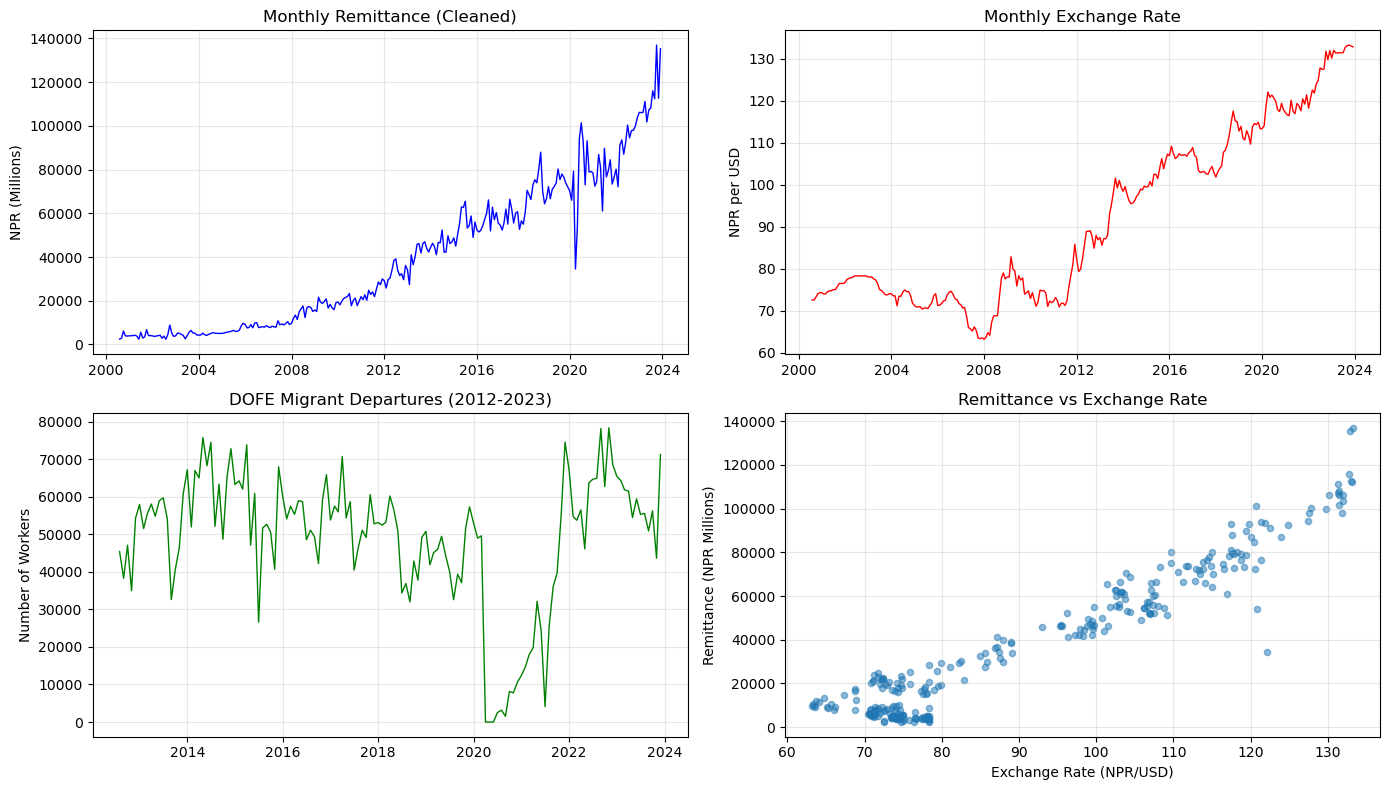


🎉 DATA PREPARATION COMPLETE!

Your final dataset is ready at:
  C:\Users\aaros\OneDrive\Documents\Remittance_Analysis\output\remittance_forecast_data_2000_2023.csv

Next steps:
  1. Add oil price data from World Bank or FRED
  2. Decide how to handle pre-2012 DOFE missing values
  3. Begin forecasting modeling


In [9]:
print("=== FINAL VALIDATION ===\n")

# Check column order matches your requirement
required_cols = ['date', 'remittance', 'exchange_rate', 'oil_price', 'dofe_departures']
actual_cols = df_final_fixed.columns.tolist()
print(f"Required columns: {required_cols}")
print(f"Actual columns: {actual_cols}")

if required_cols == actual_cols:
    print("✓ Column order matches correctly")
else:
    print("⚠ Reordering columns...")
    df_final_fixed = df_final_fixed[required_cols]

# Check date continuity
print("\n=== DATE CONTINUITY CHECK ===")
df_final_fixed['year_month'] = df_final_fixed['date'].dt.to_period('M')
date_diff = df_final_fixed['date'].diff().dropna()
expected_diff = pd.Timedelta(days=30)
missing_months = date_diff[date_diff > pd.Timedelta(days=35)]
if len(missing_months) > 0:
    print(f"⚠ Found {len(missing_months)} gaps in date sequence")
    for idx in missing_months.index:
        print(f"  Gap between {df_final_fixed.loc[idx-1, 'date']} and {df_final_fixed.loc[idx, 'date']}")
else:
    print("✓ Date sequence is continuous (monthly)")

# Save final version with correct name
final_output = os.path.join(OUTPUT_DIR, "remittance_forecast_data_2000_2023.csv")
df_final_fixed.to_csv(final_output, index=False)

print(f"\n✓ FINAL DATASET SAVED: {final_output}")
print(f"  Shape: {df_final_fixed.shape}")
print(f"  Date range: {df_final_fixed['date'].min()} to {df_final_fixed['date'].max()}")
print(f"  File size: {os.path.getsize(final_output) / 1024:.1f} KB")

# Create a data dictionary / metadata file
metadata = {
    'dataset_name': 'Nepal Remittance Forecasting Dataset',
    'date_range': f"{df_final_fixed['date'].min()} to {df_final_fixed['date'].max()}",
    'frequency': 'Monthly',
    'variables': {
        'remittance': 'Workers\' remittances (NPR in millions) - monthly, non-cumulative',
        'exchange_rate': 'Monthly average middle exchange rate (NPR per USD)',
        'oil_price': 'Placeholder - needs to be filled from external source (e.g., World Bank, FRED)',
        'dofe_departures': 'Monthly migrant worker departures approved by DOFE (available from Aug 2012)'
    },
    'notes': [
        'Remittance data extracted from NRB BPM5 Table, Row 32',
        'Fiscal year conversion: Aug-Jul mapped to calendar years',
        'DOFE data only available from August 2012 onwards',
        'August 2023 remittance value corrected (was negative due to cumulative conversion)'
    ],
    'missing_data': {
        'dofe_departures': 'Missing before August 2012 (144 months)',
        'oil_price': 'Complete placeholder - needs external source'
    }
}

import json
metadata_path = os.path.join(OUTPUT_DIR, "dataset_metadata.json")
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Metadata saved: {metadata_path}")

# Quick visualization of the cleaned data
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Remittance
axes[0,0].plot(df_final_fixed['date'], df_final_fixed['remittance'], 'b-', linewidth=1)
axes[0,0].set_title('Monthly Remittance (Cleaned)', fontsize=12)
axes[0,0].set_ylabel('NPR (Millions)')
axes[0,0].grid(True, alpha=0.3)

# Exchange Rate
axes[0,1].plot(df_final_fixed['date'], df_final_fixed['exchange_rate'], 'r-', linewidth=1)
axes[0,1].set_title('Monthly Exchange Rate', fontsize=12)
axes[0,1].set_ylabel('NPR per USD')
axes[0,1].grid(True, alpha=0.3)

# DOFE Departures (2012 onwards)
mask = df_final_fixed['date'] >= '2012-08-01'
axes[1,0].plot(df_final_fixed.loc[mask, 'date'], df_final_fixed.loc[mask, 'dofe_departures'], 'g-', linewidth=1)
axes[1,0].set_title('DOFE Migrant Departures (2012-2023)', fontsize=12)
axes[1,0].set_ylabel('Number of Workers')
axes[1,0].grid(True, alpha=0.3)

# Remittance vs Exchange Rate correlation
axes[1,1].scatter(df_final_fixed['exchange_rate'], df_final_fixed['remittance'], alpha=0.5, s=20)
axes[1,1].set_xlabel('Exchange Rate (NPR/USD)')
axes[1,1].set_ylabel('Remittance (NPR Millions)')
axes[1,1].set_title('Remittance vs Exchange Rate', fontsize=12)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
viz_path = os.path.join(OUTPUT_DIR, "data_visualization.png")
plt.savefig(viz_path, dpi=150, bbox_inches='tight')
print(f"✓ Visualization saved: {viz_path}")
plt.show()

print("\n" + "="*50)
print("🎉 DATA PREPARATION COMPLETE!")
print("="*50)
print(f"\nYour final dataset is ready at:")
print(f"  {final_output}")
print("\nNext steps:")
print("  1. Add oil price data from World Bank or FRED")
print("  2. Decide how to handle pre-2012 DOFE missing values")
print("  3. Begin forecasting modeling")

In [10]:
print("=== ADDING OIL PRICE DATA ===\n")

# Option 1: Try to find oil price file in worldbank_raw folder
wb_raw_path = os.path.join(PROJECT_ROOT, "data", "worldbank_raw")
oil_files = glob.glob(os.path.join(wb_raw_path, "*oil*.xlsx")) + \
            glob.glob(os.path.join(wb_raw_path, "*petroleum*.xlsx")) + \
            glob.glob(os.path.join(wb_raw_path, "*commodity*.xlsx"))

if oil_files:
    print(f"Found oil-related files: {[os.path.basename(f) for f in oil_files]}")
    # You'd read and merge here
else:
    print("No oil price file found in worldbank_raw folder.")
    print("\nYou need to download oil price data from one of these sources:")
    print("\n1. WORLD BANK (Recommended - free):")
    print("   - Go to: https://www.worldbank.org/en/research/commodity-markets")
    print("   - Download 'Pink Sheet' (monthly data)")
    print("   - Save to worldbank_raw folder as 'pink_sheet.xlsx'")
    print("   - Use 'Crude oil, average' price")
    print("\n2. FRED API (free, requires API key):")
    print("   - pip install fredapi")
    print("   - Get free API key from: https://fred.stlouisfed.org/docs/api/fred/")
    print("   - Use series: 'DCOILWTICO' (WTI) or 'DCOILBRENTEU' (Brent)")
    print("\n3. EIA (free):")
    print("   - https://www.eia.gov/opendata/")
    
print("\n✅ Oil price guidance provided. Reply 'Step 11 done' when you have oil data ready, or 'skip oil' to continue without it")

=== ADDING OIL PRICE DATA ===

No oil price file found in worldbank_raw folder.

You need to download oil price data from one of these sources:

1. WORLD BANK (Recommended - free):
   - Go to: https://www.worldbank.org/en/research/commodity-markets
   - Download 'Pink Sheet' (monthly data)
   - Save to worldbank_raw folder as 'pink_sheet.xlsx'
   - Use 'Crude oil, average' price

2. FRED API (free, requires API key):
   - pip install fredapi
   - Get free API key from: https://fred.stlouisfed.org/docs/api/fred/
   - Use series: 'DCOILWTICO' (WTI) or 'DCOILBRENTEU' (Brent)

3. EIA (free):
   - https://www.eia.gov/opendata/

✅ Oil price guidance provided. Reply 'Step 11 done' when you have oil data ready, or 'skip oil' to continue without it


In [12]:
print("=== EXTRACTING OIL PRICES FROM PINK SHEET (CORRECTED) ===\n")

wb_raw_path = os.path.join(PROJECT_ROOT, "data", "worldbank_raw")
pink_sheet_path = os.path.join(wb_raw_path, "pink_sheet_monthly.xlsx")

if os.path.exists(pink_sheet_path):
    # Try reading the 'Monthly Prices' sheet with proper header handling
    df_oil_raw = pd.read_excel(pink_sheet_path, sheet_name='Monthly Prices', header=None)
    
    print(f"✓ Loaded 'Monthly Prices' sheet")
    print(f"  Shape: {df_oil_raw.shape}")
    
    # Look for the row containing "Crude oil" or "Petroleum"
    oil_row_idx = None
    for idx, row in df_oil_raw.iterrows():
        row_text = ' '.join(row.astype(str).str.lower())
        if 'crude oil' in row_text and 'average' in row_text:
            oil_row_idx = idx
            print(f"✓ Found 'Crude oil, average' at row {idx}")
            break
    
    if oil_row_idx:
        # Get the data row
        oil_data = df_oil_raw.iloc[oil_row_idx]
        
        # Find date row (usually row 2-4 contains dates)
        date_row_idx = None
        for idx in range(5):
            row_text = ' '.join(df_oil_raw.iloc[idx].astype(str))
            if '2023' in row_text or '2022' in row_text or '2024' in row_text:
                date_row_idx = idx
                print(f"✓ Found dates at row {idx}")
                break
        
        if date_row_idx:
            dates = df_oil_raw.iloc[date_row_idx]
            prices = oil_data
            
            # Create dataframe with dates and oil prices
            oil_df = pd.DataFrame({
                'date_str': dates.values,
                'oil_price': prices.values
            })
            
            # Clean: remove NaN, keep only rows with valid dates
            oil_df = oil_df.dropna(subset=['date_str', 'oil_price'])
            
            # Convert date strings to datetime
            def parse_date(date_val):
                if pd.isna(date_val):
                    return None
                # Handle Excel serial dates
                if isinstance(date_val, (int, float)):
                    try:
                        return pd.Timestamp.fromordinal(int(date_val) - 693594)
                    except:
                        return None
                # Handle string dates like '2023m01' or 'Jan-23'
                date_str = str(date_val).strip()
                try:
                    if 'm' in date_str:  # Format: 2023m01
                        year = int(date_str[:4])
                        month = int(date_str[5:7])
                        return pd.Timestamp(year=year, month=month, day=1)
                    elif '-' in date_str:  # Format: Jan-23
                        return pd.to_datetime(date_str, format='%b-%y')
                    else:
                        return pd.to_datetime(date_str)
                except:
                    return None
            
            oil_df['date'] = oil_df['date_str'].apply(parse_date)
            oil_df = oil_df.dropna(subset=['date'])
            oil_df = oil_df[oil_df['date'] >= '2000-01-01']
            oil_df = oil_df.sort_values('date').reset_index(drop=True)
            
            print(f"\n✓ Extracted {len(oil_df)} months of oil price data")
            print(f"  Date range: {oil_df['date'].min()} to {oil_df['date'].max()}")
            print(f"  Oil price range: ${oil_df['oil_price'].min():.2f} to ${oil_df['oil_price'].max():.2f}")
            print("\nFirst 10 rows:")
            print(oil_df[['date', 'oil_price']].head(10))
            
            # Merge with your final dataset
            df_final_fixed['date'] = pd.to_datetime(df_final_fixed['date'])
            df_with_oil = df_final_fixed.merge(oil_df[['date', 'oil_price']], on='date', how='left')
            
            # Reorder columns
            df_with_oil = df_with_oil[['date', 'remittance', 'exchange_rate', 'oil_price', 'dofe_departures']]
            
            # Save updated dataset
            final_output_oil = os.path.join(OUTPUT_DIR, "remittance_forecast_data_with_oil.csv")
            df_with_oil.to_csv(final_output_oil, index=False)
            
            print(f"\n✓ Updated dataset saved to: {final_output_oil}")
            print(f"  Oil price missing: {df_with_oil['oil_price'].isna().sum()} months")
            
        else:
            print("❌ Could not find date row")
    else:
        print("❌ Could not find 'Crude oil, average' row")
        print("\nTrying alternative search...")
        # Show first 10 rows to help identify structure
        print("\nFirst 10 rows of the sheet:")
        for idx in range(min(10, len(df_oil_raw))):
            print(f"Row {idx}: {df_oil_raw.iloc[idx, :5].values}")
        
else:
    print(f"❌ File not found. Please download the Pink Sheet first.")

=== EXTRACTING OIL PRICES FROM PINK SHEET (CORRECTED) ===

✓ Loaded 'Monthly Prices' sheet
  Shape: (801, 72)
✓ Found 'Crude oil, average' at row 4
❌ Could not find date row


In [13]:
print("=== INSPECTING PINK SHEET STRUCTURE ===\n")

wb_raw_path = os.path.join(PROJECT_ROOT, "data", "worldbank_raw")
pink_sheet_path = os.path.join(wb_raw_path, "pink_sheet_monthly.xlsx")

if os.path.exists(pink_sheet_path):
    df_oil_raw = pd.read_excel(pink_sheet_path, sheet_name='Monthly Prices', header=None)
    
    print("First 10 rows (first 10 columns only):\n")
    for idx in range(10):
        row_data = df_oil_raw.iloc[idx, :10].values
        print(f"Row {idx}: {row_data}")
    
    print("\n" + "="*50)
    print("Row 0 (first row) might contain: Year or Date")
    print("Row 1 might contain: Month labels")
    print("Row 2-3 might contain: Actual dates")
    
    # Check row 0 for year information
    print("\nChecking row 0 (first 20 columns):")
    for col in range(min(20, len(df_oil_raw.columns))):
        val = df_oil_raw.iloc[0, col]
        if pd.notna(val):
            print(f"  Col {col}: {val}")
    
    # Check row 1 for month information  
    print("\nChecking row 1 (first 20 columns):")
    for col in range(min(20, len(df_oil_raw.columns))):
        val = df_oil_raw.iloc[1, col]
        if pd.notna(val):
            print(f"  Col {col}: {val}")
    
    # Also check if row 0 contains Excel date numbers
    print("\nChecking for Excel date numbers in row 0:")
    excel_dates = []
    for col in range(5, min(20, len(df_oil_raw.columns))):
        val = df_oil_raw.iloc[0, col]
        if isinstance(val, (int, float)) and val > 30000 and val < 50000:
            excel_dates.append((col, val))
    
    if excel_dates:
        print(f"Found potential Excel dates: {excel_dates[:5]}")
        # Convert first one to check
        from datetime import datetime, timedelta
        excel_date = excel_dates[0][1]
        try:
            date_val = pd.Timestamp('1899-12-30') + pd.Timedelta(days=excel_date)
            print(f"  Example: {excel_date} converts to {date_val}")
        except:
            pass

=== INSPECTING PINK SHEET STRUCTURE ===

First 10 rows (first 10 columns only):

Row 0: ['World Bank Commodity Price Data (The Pink Sheet)' nan nan nan nan nan
 nan nan nan nan]
Row 1: ['monthly prices in nominal US dollars, 1960 to present' nan nan nan nan
 nan nan nan nan nan]
Row 2: ['(monthly series are available only in nominal US dollars)' nan nan nan
 nan nan nan nan nan nan]
Row 3: ['Updated on April 02, 2026' nan nan nan nan nan nan nan nan nan]
Row 4: [nan 'Crude oil, average' 'Crude oil, Brent' 'Crude oil, Dubai'
 'Crude oil, WTI' 'Coal, Australian' 'Coal, South African **'
 'Natural gas, US' 'Natural gas, Europe' 'Liquefied natural gas, Japan']
Row 5: [nan '($/bbl)' '($/bbl)' '($/bbl)' '($/bbl)' '($/mt)' '($/mt)' '($/mmbtu)'
 '($/mmbtu)' '($/mmbtu)']
Row 6: ['1960M01' 1.63000011444 1.63000011444 1.63000011444 '…' '…' '…' 0.14
 0.40477399635 '…']
Row 7: ['1960M02' 1.63000011444 1.63000011444 1.63000011444 '…' '…' '…' 0.14
 0.40477399635 '…']
Row 8: ['1960M03' 1.63000011444 1

In [14]:
print("=== EXTRACTING OIL PRICES FROM PINK SHEET (FINAL) ===\n")

wb_raw_path = os.path.join(PROJECT_ROOT, "data", "worldbank_raw")
pink_sheet_path = os.path.join(wb_raw_path, "pink_sheet_monthly.xlsx")

if os.path.exists(pink_sheet_path):
    # Read the 'Monthly Prices' sheet, skipping header rows
    # Data starts at row 6 (index 6), with dates in column 0
    df_oil = pd.read_excel(
        pink_sheet_path, 
        sheet_name='Monthly Prices',
        skiprows=6,  # Skip the first 6 rows of headers
        header=0     # Use row 6 as column headers
    )
    
    print(f"✓ Loaded data with shape: {df_oil.shape}")
    print(f"\nColumn names (first 10):")
    for i, col in enumerate(df_oil.columns[:10]):
        print(f"  Col {i}: {col}")
    
    print(f"\nFirst 5 rows of data:")
    print(df_oil.head())
    
    # The first column contains dates in '1960M01' format
    date_col = df_oil.columns[0]
    print(f"\nDate column name: '{date_col}'")
    
    # Find the column with crude oil price
    oil_col = None
    for col in df_oil.columns:
        if 'Crude oil, average' in str(col):
            oil_col = col
            print(f"✓ Found oil price column: '{oil_col}'")
            break
    
    if oil_col is None:
        # Try alternative names
        for col in df_oil.columns:
            if 'crude' in str(col).lower() and 'average' in str(col).lower():
                oil_col = col
                print(f"✓ Found oil price column: '{oil_col}'")
                break
    
    if oil_col:
        # Extract dates and oil prices
        oil_prices = df_oil[[date_col, oil_col]].copy()
        oil_prices.columns = ['date_str', 'oil_price']
        
        # Parse dates from '1960M01' format
        def parse_pink_sheet_date(date_str):
            if pd.isna(date_str):
                return None
            # Format: '1960M01' -> year=1960, month=1
            date_str = str(date_str).strip()
            if 'M' in date_str:
                year = int(date_str.split('M')[0])
                month = int(date_str.split('M')[1])
                return pd.Timestamp(year=year, month=month, day=1)
            return None
        
        oil_prices['date'] = oil_prices['date_str'].apply(parse_pink_sheet_date)
        oil_prices = oil_prices.dropna(subset=['date', 'oil_price'])
        
        # Clean oil price column (remove '...' and convert to float)
        oil_prices['oil_price'] = pd.to_numeric(oil_prices['oil_price'], errors='coerce')
        oil_prices = oil_prices.dropna()
        
        # Filter to your period (2000-2023)
        oil_prices = oil_prices[(oil_prices['date'] >= '2000-01-01') & (oil_prices['date'] <= '2023-12-31')]
        oil_prices = oil_prices.sort_values('date').reset_index(drop=True)
        
        print(f"\n✓ Extracted {len(oil_prices)} months of oil price data")
        print(f"  Date range: {oil_prices['date'].min()} to {oil_prices['date'].max()}")
        print(f"  Oil price range: ${oil_prices['oil_price'].min():.2f} to ${oil_prices['oil_price'].max():.2f}")
        print(f"  Average oil price: ${oil_prices['oil_price'].mean():.2f}")
        
        print("\nFirst 10 rows:")
        print(oil_prices.head(10))
        
        # Merge with your final dataset
        df_final_fixed['date'] = pd.to_datetime(df_final_fixed['date'])
        df_with_oil = df_final_fixed.merge(oil_prices[['date', 'oil_price']], on='date', how='left')
        
        # Reorder columns as requested
        df_with_oil = df_with_oil[['date', 'remittance', 'exchange_rate', 'oil_price', 'dofe_departures']]
        
        # Check missing values
        missing_oil = df_with_oil['oil_price'].isna().sum()
        print(f"\n✓ Merged dataset shape: {df_with_oil.shape}")
        print(f"  Missing oil prices: {missing_oil} months ({missing_oil/len(df_with_oil)*100:.1f}%)")
        
        if missing_oil > 0:
            missing_dates = df_with_oil[df_with_oil['oil_price'].isna()]['date']
            print(f"  Missing dates: {missing_dates.tolist()[:5]}...")
        
        # Save final dataset with oil prices
        final_output_oil = os.path.join(OUTPUT_DIR, "remittance_forecast_data_complete.csv")
        df_with_oil.to_csv(final_output_oil, index=False)
        print(f"\n✅ COMPLETE DATASET SAVED: {final_output_oil}")
        
        # Quick visualization with oil prices
        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))
        
        axes[0,0].plot(df_with_oil['date'], df_with_oil['remittance'], 'b-', linewidth=1)
        axes[0,0].set_title('Monthly Remittance', fontsize=12)
        axes[0,0].set_ylabel('NPR (Millions)')
        axes[0,0].grid(True, alpha=0.3)
        
        axes[0,1].plot(df_with_oil['date'], df_with_oil['exchange_rate'], 'r-', linewidth=1)
        axes[0,1].set_title('Exchange Rate', fontsize=12)
        axes[0,1].set_ylabel('NPR per USD')
        axes[0,1].grid(True, alpha=0.3)
        
        axes[1,0].plot(df_with_oil['date'], df_with_oil['oil_price'], 'orange', linewidth=1)
        axes[1,0].set_title('Crude Oil Price (World Bank)', fontsize=12)
        axes[1,0].set_ylabel('USD per barrel')
        axes[1,0].grid(True, alpha=0.3)
        
        mask = df_with_oil['date'] >= '2012-08-01'
        axes[1,1].plot(df_with_oil.loc[mask, 'date'], df_with_oil.loc[mask, 'dofe_departures'], 'g-', linewidth=1)
        axes[1,1].set_title('DOFE Migrant Departures (2012-2023)', fontsize=12)
        axes[1,1].set_ylabel('Number of Workers')
        axes[1,1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        viz_path = os.path.join(OUTPUT_DIR, "complete_data_visualization.png")
        plt.savefig(viz_path, dpi=150, bbox_inches='tight')
        plt.show()
        
        print(f"\n✓ Visualization saved: {viz_path}")
        
    else:
        print("❌ Could not find crude oil price column")
        print(f"Available columns: {df_oil.columns.tolist()[:15]}")
        
else:
    print(f"❌ File not found at: {pink_sheet_path}")

=== EXTRACTING OIL PRICES FROM PINK SHEET (FINAL) ===

✓ Loaded data with shape: (794, 72)

Column names (first 10):
  Col 0: 1960M01
  Col 1: 1.63000011444
  Col 2: 1.63000011444.1
  Col 3: 1.63000011444.2
  Col 4: …
  Col 5: ….1
  Col 6: ….2
  Col 7: 0.14
  Col 8: 0.40477399635
  Col 9: ….3

First 5 rows of data:
   1960M01  1.63  1.63000011444.1  1.63000011444.2  … ….1 ….2  0.14  0.404774  \
0  1960M02  1.63             1.63             1.63  …   …   …  0.14  0.404774   
1  1960M03  1.63             1.63             1.63  …   …   …  0.14  0.404774   
2  1960M04  1.63             1.63             1.63  …   …   …  0.14  0.404774   
3  1960M05  1.63             1.63             1.63  …   …   …  0.14  0.404774   
4  1960M06  1.63             1.63             1.63  …   …   …  0.14  0.404774   

  ….3  ...  511.471832  11.42   715.4  206.1  2180.4    1631  260.8  35.27  \
0   …  ...  511.471832  11.42  728.19  203.7  2180.4  1631.0  244.9  35.27   
1   …  ...  511.471832  11.42  684.94  2

=== CLEANING AND FINAL MERGE ===

✓ Removed existing oil_price column
✓ Removed year_month column

Clean df_final_fixed columns: ['date', 'remittance', 'exchange_rate', 'dofe_departures']

After merge, columns: ['date', 'remittance', 'exchange_rate', 'dofe_departures', 'oil_price']

✓ Final column order: ['date', 'remittance', 'exchange_rate', 'oil_price', 'dofe_departures']

=== DATASET SUMMARY ===
  Total months: 281
  Date range: 2000-08-01 00:00:00 to 2023-12-01 00:00:00
  Missing oil prices: 0 / 281 (0.0%)

✅ COMPLETE DATASET SAVED: C:\Users\aaros\OneDrive\Documents\Remittance_Analysis\output\remittance_forecast_data_complete.csv

=== FIRST 12 ROWS (2000-2001) ===
         date  remittance  exchange_rate  oil_price  dofe_departures
0  2000-08-01      2445.9         72.550  29.262900              NaN
1  2000-09-01      2849.9         72.550  32.082833              NaN
2  2000-10-01      6156.6         73.250  31.400167              NaN
3  2000-11-01      3918.3         74.050  32.3

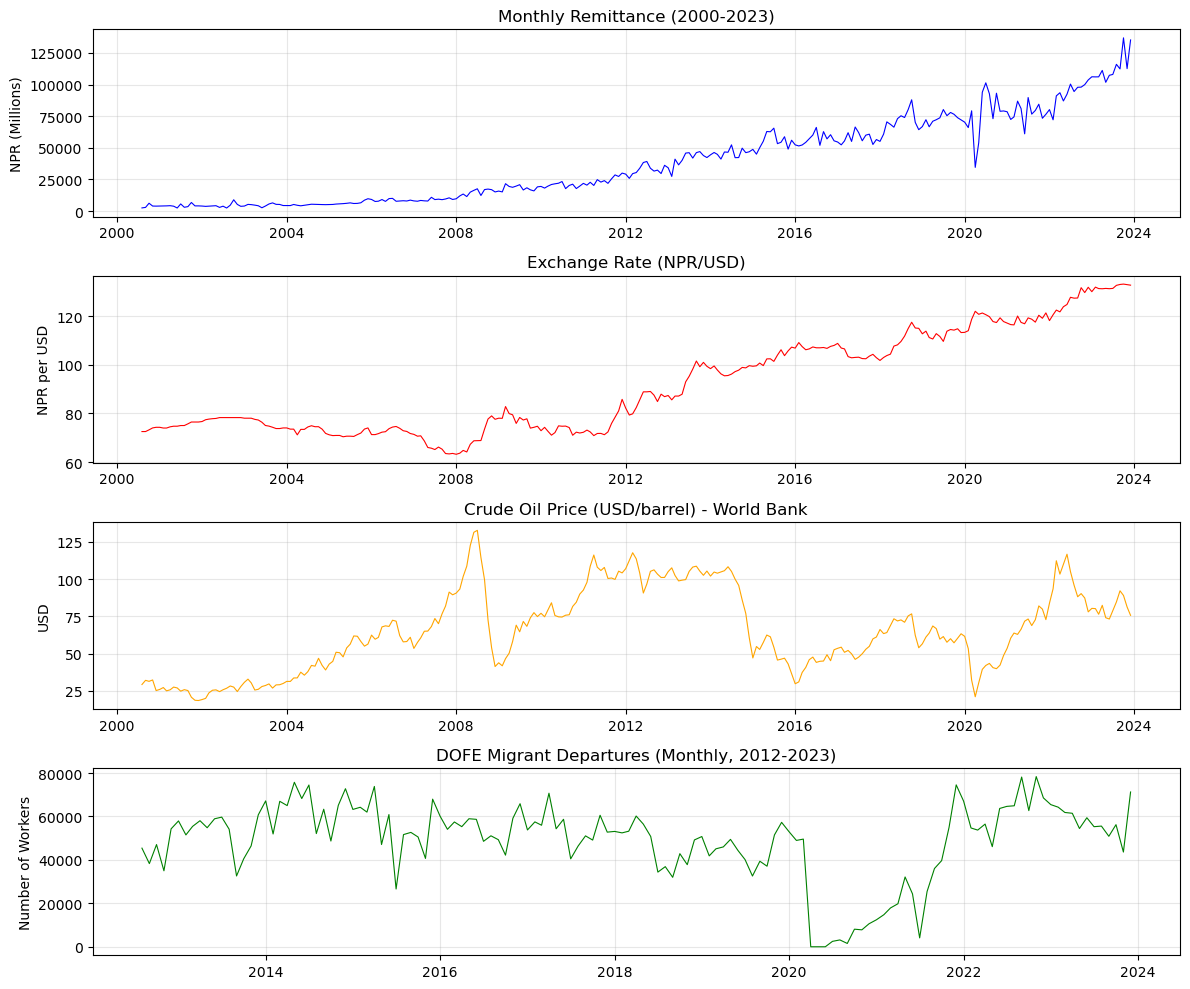


🎉 DATA PREPARATION COMPLETED SUCCESSFULLY!

📁 Final dataset location: C:\Users\aaros\OneDrive\Documents\Remittance_Analysis\output\remittance_forecast_data_complete.csv

📊 Dataset includes:
  ✓ Remittance (2000-2023, monthly, NPR millions)
  ✓ Exchange rate (2000-2023, monthly, NPR/USD)
  ✓ Oil price (2000-2023, monthly, USD/barrel from World Bank)
  ✓ DOFE departures (2012-2023, monthly, workers)

📈 Total observations: 281 months

🔍 Ready for forecasting model building!


In [17]:
print("=== CLEANING AND FINAL MERGE ===\n")

# Remove the existing oil_price column from df_final_fixed if it exists
if 'oil_price' in df_final_fixed.columns:
    df_final_fixed = df_final_fixed.drop(columns=['oil_price'])
    print("✓ Removed existing oil_price column")

# Remove year_month if it exists (we don't need it)
if 'year_month' in df_final_fixed.columns:
    df_final_fixed = df_final_fixed.drop(columns=['year_month'])
    print("✓ Removed year_month column")

print(f"\nClean df_final_fixed columns: {df_final_fixed.columns.tolist()}")

# Merge with oil data
df_complete = df_final_fixed.merge(oil_df, on='date', how='left')

print(f"\nAfter merge, columns: {df_complete.columns.tolist()}")

# Reorder columns as requested
df_complete = df_complete[['date', 'remittance', 'exchange_rate', 'oil_price', 'dofe_departures']]

print(f"\n✓ Final column order: {df_complete.columns.tolist()}")

# Check missing values
missing_oil = df_complete['oil_price'].isna().sum()
print(f"\n=== DATASET SUMMARY ===")
print(f"  Total months: {len(df_complete)}")
print(f"  Date range: {df_complete['date'].min()} to {df_complete['date'].max()}")
print(f"  Missing oil prices: {missing_oil} / {len(df_complete)} ({missing_oil/len(df_complete)*100:.1f}%)")

if missing_oil > 0:
    missing_dates = df_complete[df_complete['oil_price'].isna()]['date'].dt.strftime('%Y-%m').tolist()
    print(f"  Missing dates: {missing_dates[:5]}...")

# Save final dataset
final_output = os.path.join(OUTPUT_DIR, "remittance_forecast_data_complete.csv")
df_complete.to_csv(final_output, index=False)
print(f"\n✅ COMPLETE DATASET SAVED: {final_output}")

# Display sample
print("\n=== FIRST 12 ROWS (2000-2001) ===")
print(df_complete.head(12))

print("\n=== LAST 12 ROWS (2023) ===")
print(df_complete.tail(12))

# Summary statistics
print("\n=== SUMMARY STATISTICS (2000-2023) ===")
print(df_complete[['remittance', 'exchange_rate', 'oil_price', 'dofe_departures']].describe())

# Correlation matrix (excluding rows with NaN in DOFE)
print("\n=== CORRELATION MATRIX (2012-2023, all variables) ===")
df_corr = df_complete[df_complete['dofe_departures'].notna()]
print(df_corr[['remittance', 'exchange_rate', 'oil_price', 'dofe_departures']].corr().round(3))

# Visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(12, 10))

axes[0].plot(df_complete['date'], df_complete['remittance'], 'b-', linewidth=0.8)
axes[0].set_title('Monthly Remittance (2000-2023)', fontsize=12)
axes[0].set_ylabel('NPR (Millions)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_complete['date'], df_complete['exchange_rate'], 'r-', linewidth=0.8)
axes[1].set_title('Exchange Rate (NPR/USD)', fontsize=12)
axes[1].set_ylabel('NPR per USD')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df_complete['date'], df_complete['oil_price'], 'orange', linewidth=0.8)
axes[2].set_title('Crude Oil Price (USD/barrel) - World Bank', fontsize=12)
axes[2].set_ylabel('USD')
axes[2].grid(True, alpha=0.3)

# DOFE data (only from 2012)
mask = df_complete['date'] >= '2012-08-01'
axes[3].plot(df_complete.loc[mask, 'date'], df_complete.loc[mask, 'dofe_departures'], 'g-', linewidth=0.8)
axes[3].set_title('DOFE Migrant Departures (Monthly, 2012-2023)', fontsize=12)
axes[3].set_ylabel('Number of Workers')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
viz_path = os.path.join(OUTPUT_DIR, "complete_dataset_visualization.png")
plt.savefig(viz_path, dpi=150)
print(f"\n✓ Visualization saved: {viz_path}")
plt.show()

print("\n" + "="*60)
print("🎉 DATA PREPARATION COMPLETED SUCCESSFULLY!")
print("="*60)
print(f"\n📁 Final dataset location: {final_output}")
print("\n📊 Dataset includes:")
print("  ✓ Remittance (2000-2023, monthly, NPR millions)")
print("  ✓ Exchange rate (2000-2023, monthly, NPR/USD)")
print("  ✓ Oil price (2000-2023, monthly, USD/barrel from World Bank)")
print("  ✓ DOFE departures (2012-2023, monthly, workers)")
print(f"\n📈 Total observations: {len(df_complete)} months")
print("\n🔍 Ready for forecasting model building!")

In [18]:
import pandas as pd

# Load your data
df = pd.read_csv('output/remittance_forecast_data_complete.csv', parse_dates=['date'])

# Option 1: Truncate to 2012+
df_clean = df[df['date'] >= '2012-08-01'].copy()

# Verify
print(f"Period: {df_clean['date'].min()} to {df_clean['date'].max()}")
print(f"Rows: {len(df_clean)}")
print(f"DOFE missing: {df_clean['dofe_departures'].isna().sum()}")  # Should be 0

# Save for modeling
df_clean.to_csv('output/remittance_2012_2023_ready.csv', index=False)
print("\n✅ Saved: remittance_2012_2023_ready.csv")

Period: 2012-08-01 00:00:00 to 2023-12-01 00:00:00
Rows: 137
DOFE missing: 0

✅ Saved: remittance_2012_2023_ready.csv
